# Plot single localization result

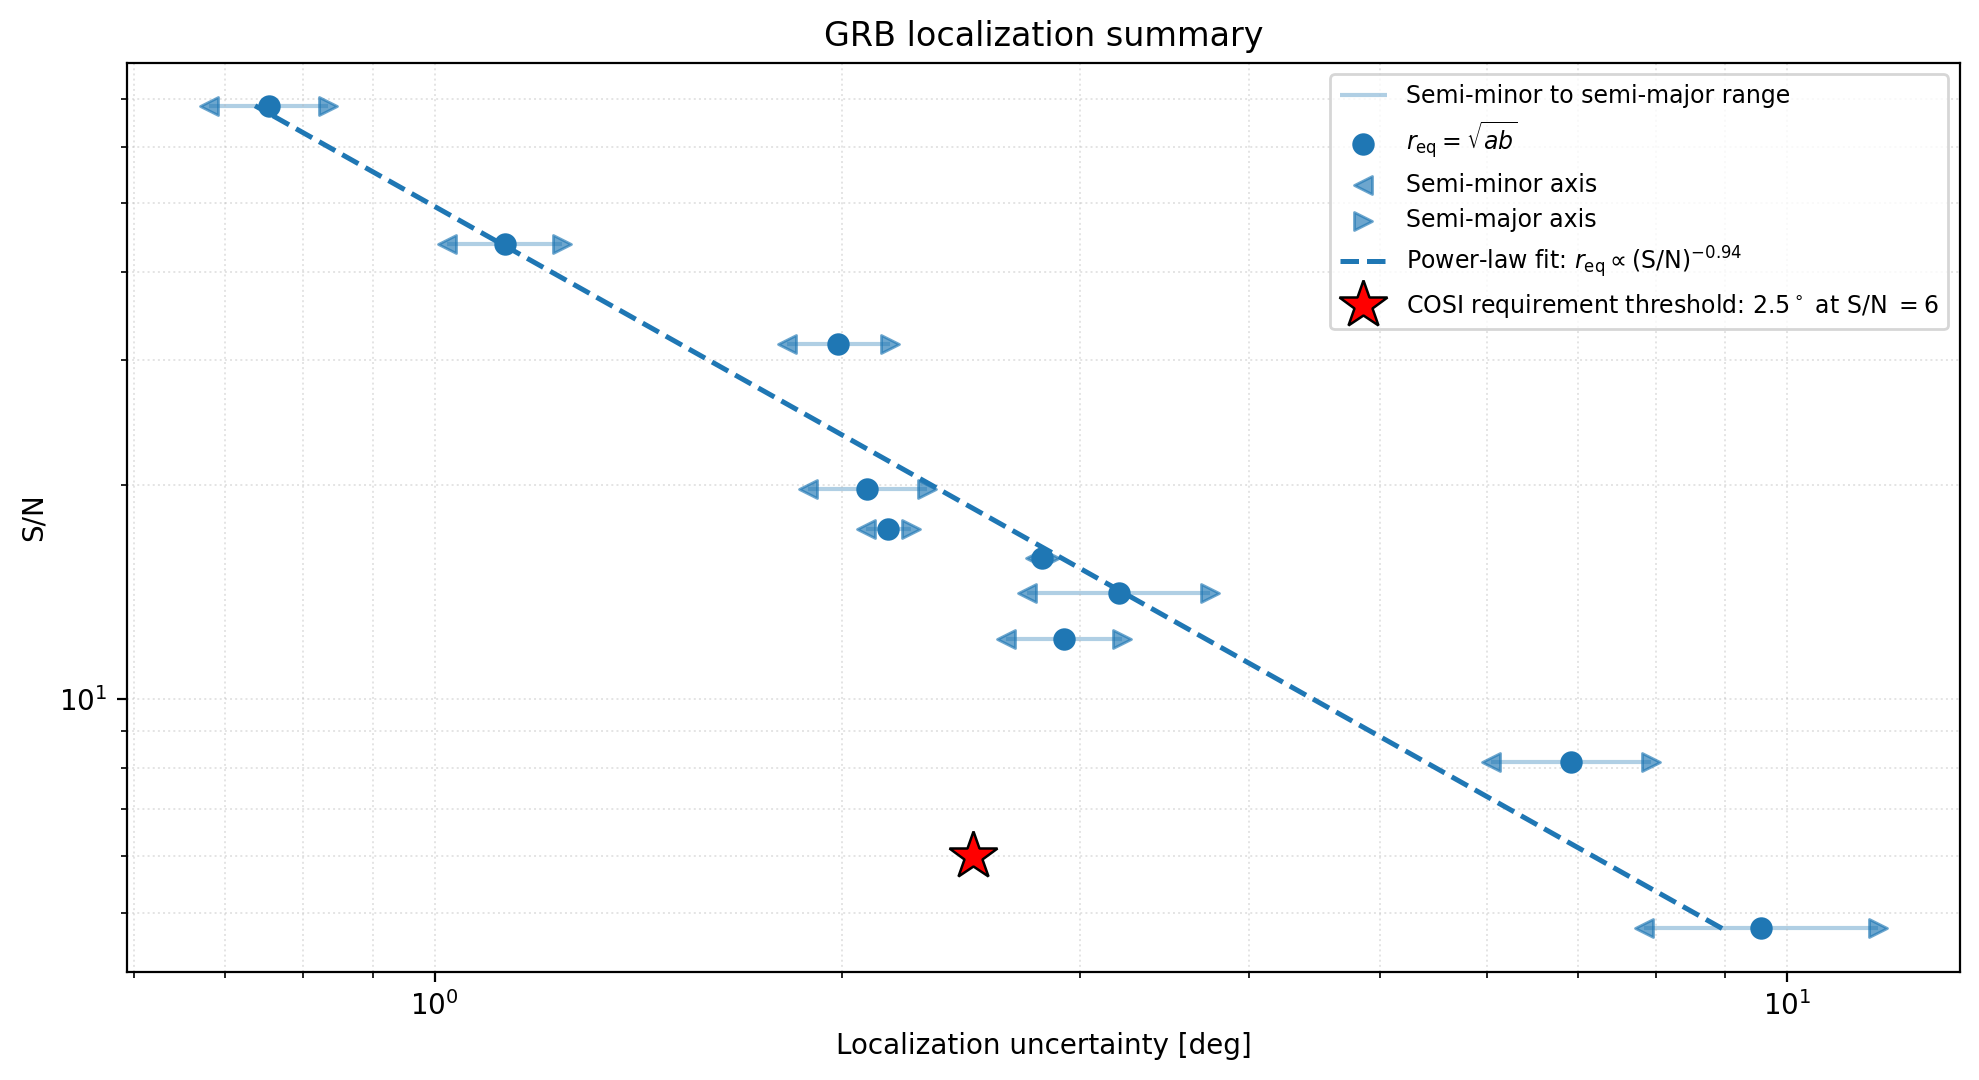

Local-background localization summary
  Number of GRBs:          10
  S/N range:               4.750–68.530

  Median semi-major axis:  2.580 deg
  Median semi-minor axis:  2.365 deg
  Median r_eq:             2.489 deg
  Mean r_eq:               3.354 deg
  Minimum r_eq:            0.754 deg
  Maximum r_eq:            9.561 deg

Power-law fitting
  Model:                   r_eq = normalization * (S/N)**slope
  Trend slope:             -0.936
  Trend normalization:     38.447
  R-squared:               0.950
  RMSE in log10 space:     0.069 dex
  Typical scatter factor:  1.173

COSI requirement
  Requirement threshold:   2.5 deg at S/N = 6.0
  Fitted r_eq at S/N = 6:  7.192 deg


In [8]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Input data: local background
#
# For every index i:
#     snr[i], a[i], and b[i]
# must belong to the same GRB.
# ============================================================
snr = np.array([
    15.79, 8.15, 43.71, 31.64, 4.75,
    19.76, 17.38, 14.10, 12.15, 68.53,
])

a = np.array([
    2.84902822, 6.03768426, 1.24332419, 2.16954255,
    11.66786767, 2.31106241, 2.08366530, 3.74613958,
    3.22030070, 0.83486117,
])

b = np.array([
    2.77970578, 7.93152180, 1.02217753, 1.82130352,
    7.83534874, 1.88778267, 2.24840521, 2.73982822,
    2.64638959, 0.68107531,
])


# ============================================================
# Configuration
# ============================================================
output_stem = "local_background_localization_summary"

figure_size = (10, 5.5)
display_dpi = 200
save_dpi = 300

# COSI localization requirement threshold
requirement_localization = 2.5  # deg
requirement_snr = 6.0


# ============================================================
# Helper functions
# ============================================================
def calculate_localization_quantities(a, b):
    """
    Calculate the semi-major axis, semi-minor axis, and equivalent
    circular localization radius.

    The equivalent circular radius preserves ellipse area:

        pi * r_eq**2 = pi * a_major * b_minor

    Therefore:

        r_eq = sqrt(a_major * b_minor)
    """
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)

    a_major = np.maximum(a, b)
    b_minor = np.minimum(a, b)
    r_eq = np.sqrt(a_major * b_minor)

    return a_major, b_minor, r_eq


def fit_power_law(snr, localization):
    """
    Fit the power-law relation

        localization = normalization * snr**slope

    using ordinary least squares in log10 space:

        log10(localization)
            = slope * log10(snr) + log10(normalization)
    """
    snr = np.asarray(snr, dtype=float)
    localization = np.asarray(localization, dtype=float)

    valid = (
        np.isfinite(snr)
        & np.isfinite(localization)
        & (snr > 0)
        & (localization > 0)
    )

    if np.count_nonzero(valid) < 2:
        raise ValueError(
            "At least two finite and positive data points are "
            "required for power-law fitting."
        )

    log_snr = np.log10(snr[valid])
    log_localization = np.log10(localization[valid])

    slope, log10_normalization = np.polyfit(
        log_snr,
        log_localization,
        deg=1,
    )

    normalization = 10**log10_normalization

    return slope, normalization


def evaluate_power_law_fit(
    snr,
    localization,
    slope,
    normalization,
):
    """
    Evaluate the fitted power law in log10 space.

    Returns
    -------
    r_squared : float
        Coefficient of determination in log10 space.

    rmse_dex : float
        Root-mean-square residual in dex.

    scatter_factor : float
        Multiplicative scatter corresponding to the RMSE.
    """
    snr = np.asarray(snr, dtype=float)
    localization = np.asarray(localization, dtype=float)

    valid = (
        np.isfinite(snr)
        & np.isfinite(localization)
        & (snr > 0)
        & (localization > 0)
    )

    snr_valid = snr[valid]
    localization_valid = localization[valid]

    fitted_localization = (
        normalization * snr_valid**slope
    )

    log_observed = np.log10(localization_valid)
    log_fitted = np.log10(fitted_localization)

    residuals = log_observed - log_fitted

    ss_residual = np.sum(residuals**2)
    ss_total = np.sum(
        (log_observed - np.mean(log_observed))**2
    )

    if np.isclose(ss_total, 0):
        r_squared = np.nan
    else:
        r_squared = 1 - ss_residual / ss_total

    rmse_dex = np.sqrt(np.mean(residuals**2))
    scatter_factor = 10**rmse_dex

    return r_squared, rmse_dex, scatter_factor


# ============================================================
# Input validation
# ============================================================
snr = np.asarray(snr, dtype=float)
a = np.asarray(a, dtype=float)
b = np.asarray(b, dtype=float)

if not (len(snr) == len(a) == len(b)):
    raise ValueError(
        "snr, a, and b must have the same number of entries."
    )

if len(snr) == 0:
    raise ValueError("The input arrays are empty.")

valid_input = (
    np.isfinite(snr)
    & np.isfinite(a)
    & np.isfinite(b)
    & (snr > 0)
    & (a > 0)
    & (b > 0)
)

if not np.all(valid_input):
    number_removed = np.count_nonzero(~valid_input)

    print(
        f"Warning: removing {number_removed} invalid data point(s)."
    )

    snr = snr[valid_input]
    a = a[valid_input]
    b = b[valid_input]


# ============================================================
# Calculate localization quantities
# ============================================================
a_major, b_minor, r_eq = (
    calculate_localization_quantities(a, b)
)


# ============================================================
# Fit power-law relation
#
#     r_eq = normalization * (S/N)**slope
# ============================================================
slope, normalization = fit_power_law(
    snr,
    r_eq,
)

r_squared, rmse_dex, scatter_factor = (
    evaluate_power_law_fit(
        snr,
        r_eq,
        slope,
        normalization,
    )
)


# Fitted localization at the requirement S/N
r_eq_at_requirement_snr = (
    normalization * requirement_snr**slope
)


# ============================================================
# Generate smooth fitted curve
#
# Include S/N = 6 in the fitted-curve range so that the curve
# reaches the requirement threshold even for future datasets.
# ============================================================
snr_grid_min = min(
    snr.min(),
    requirement_snr,
)

snr_grid_max = max(
    snr.max(),
    requirement_snr,
)

snr_grid = np.logspace(
    np.log10(snr_grid_min),
    np.log10(snr_grid_max),
    500,
)

r_eq_fit = normalization * snr_grid**slope


# ============================================================
# Plot
# ============================================================
# Remove any old figures retained by Jupyter.
plt.close("all")

fig, ax = plt.subplots(
    figsize=figure_size,
    dpi=display_dpi,
)


# Horizontal range from semi-minor to semi-major axis
ax.hlines(
    y=snr,
    xmin=b_minor,
    xmax=a_major,
    color="tab:blue",
    linewidth=1.5,
    alpha=0.35,
    label="Semi-minor to semi-major range",
    zorder=1,
)


# Equivalent circular localization radius
ax.scatter(
    r_eq,
    snr,
    marker="o",
    s=50,
    color="tab:blue",
    label=r"$r_{\rm eq}=\sqrt{ab}$",
    zorder=3,
)


# Semi-minor axis
ax.scatter(
    b_minor,
    snr,
    marker="<",
    s=42,
    color="tab:blue",
    alpha=0.65,
    label="Semi-minor axis",
    zorder=3,
)


# Semi-major axis
ax.scatter(
    a_major,
    snr,
    marker=">",
    s=42,
    color="tab:blue",
    alpha=0.65,
    label="Semi-major axis",
    zorder=3,
)


# Power-law fitted trend
ax.plot(
    r_eq_fit,
    snr_grid,
    linestyle="--",
    linewidth=1.8,
    color="tab:blue",
    label=(
        rf"Power-law fit: "
        rf"$r_{{\rm eq}}\propto"
        rf"(\mathrm{{S/N}})^{{{slope:.2f}}}$"
    ),
    zorder=2,
)


# ============================================================
# COSI requirement threshold
#
# Acceptable region is:
#
#     localization uncertainty < 2.5 deg
#     S/N > 6
#
# The star marks the boundary point (2.5 deg, 6).
# ============================================================
ax.plot(
    requirement_localization,
    requirement_snr,
    linestyle="none",
    marker="*",
    markersize=18,
    markerfacecolor="red",
    markeredgecolor="black",
    markeredgewidth=0.9,
    label=(
        r"COSI requirement threshold: "
        r"$2.5^\circ$ at S/N $=6$"
    ),
    zorder=10,
)


# ============================================================
# Axes and formatting
# ============================================================
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Localization uncertainty [deg]")
ax.set_ylabel("S/N")

ax.set_title("GRB localization summary")


# Explicitly include the requirement point in the axis limits.
# This also keeps the star visible for future datasets whose
# numerical ranges do not naturally include x=2.5 or y=6.
all_x_values = np.concatenate([
    b_minor,
    a_major,
    r_eq,
    r_eq_fit,
    [requirement_localization],
])

all_y_values = np.concatenate([
    snr,
    snr_grid,
    [requirement_snr],
])

axis_padding_factor = 1.15

ax.set_xlim(
    all_x_values.min() / axis_padding_factor,
    all_x_values.max() * axis_padding_factor,
)

ax.set_ylim(
    all_y_values.min() / axis_padding_factor,
    all_y_values.max() * axis_padding_factor,
)


ax.grid(
    which="both",
    linestyle=":",
    linewidth=0.7,
    alpha=0.35,
)

ax.legend(
    fontsize=8.5,
    frameon=True,
)

fig.tight_layout()


# ============================================================
# Save and display figure
# ============================================================
fig.savefig(
    f"{output_stem}.png",
    dpi=save_dpi,
    bbox_inches="tight",
)

fig.savefig(
    f"{output_stem}.pdf",
    bbox_inches="tight",
)

plt.show()


# ============================================================
# Numerical summary
# ============================================================
print("Local-background localization summary")
print(f"  Number of GRBs:          {len(snr)}")
print(f"  S/N range:               {snr.min():.3f}–{snr.max():.3f}")
print()
print(f"  Median semi-major axis:  {np.median(a_major):.3f} deg")
print(f"  Median semi-minor axis:  {np.median(b_minor):.3f} deg")
print(f"  Median r_eq:             {np.median(r_eq):.3f} deg")
print(f"  Mean r_eq:               {np.mean(r_eq):.3f} deg")
print(f"  Minimum r_eq:            {np.min(r_eq):.3f} deg")
print(f"  Maximum r_eq:            {np.max(r_eq):.3f} deg")

print()
print("Power-law fitting")
print(
    "  Model:                   "
    "r_eq = normalization * (S/N)**slope"
)
print(f"  Trend slope:             {slope:.3f}")
print(f"  Trend normalization:     {normalization:.3f}")
print(f"  R-squared:               {r_squared:.3f}")
print(f"  RMSE in log10 space:     {rmse_dex:.3f} dex")
print(f"  Typical scatter factor:  {scatter_factor:.3f}")

print()
print("COSI requirement")
print(
    f"  Requirement threshold:   "
    f"{requirement_localization:.1f} deg at S/N = "
    f"{requirement_snr:.1f}"
)
print(
    f"  Fitted r_eq at S/N = 6:  "
    f"{r_eq_at_requirement_snr:.3f} deg"
)

# Compare two localization results

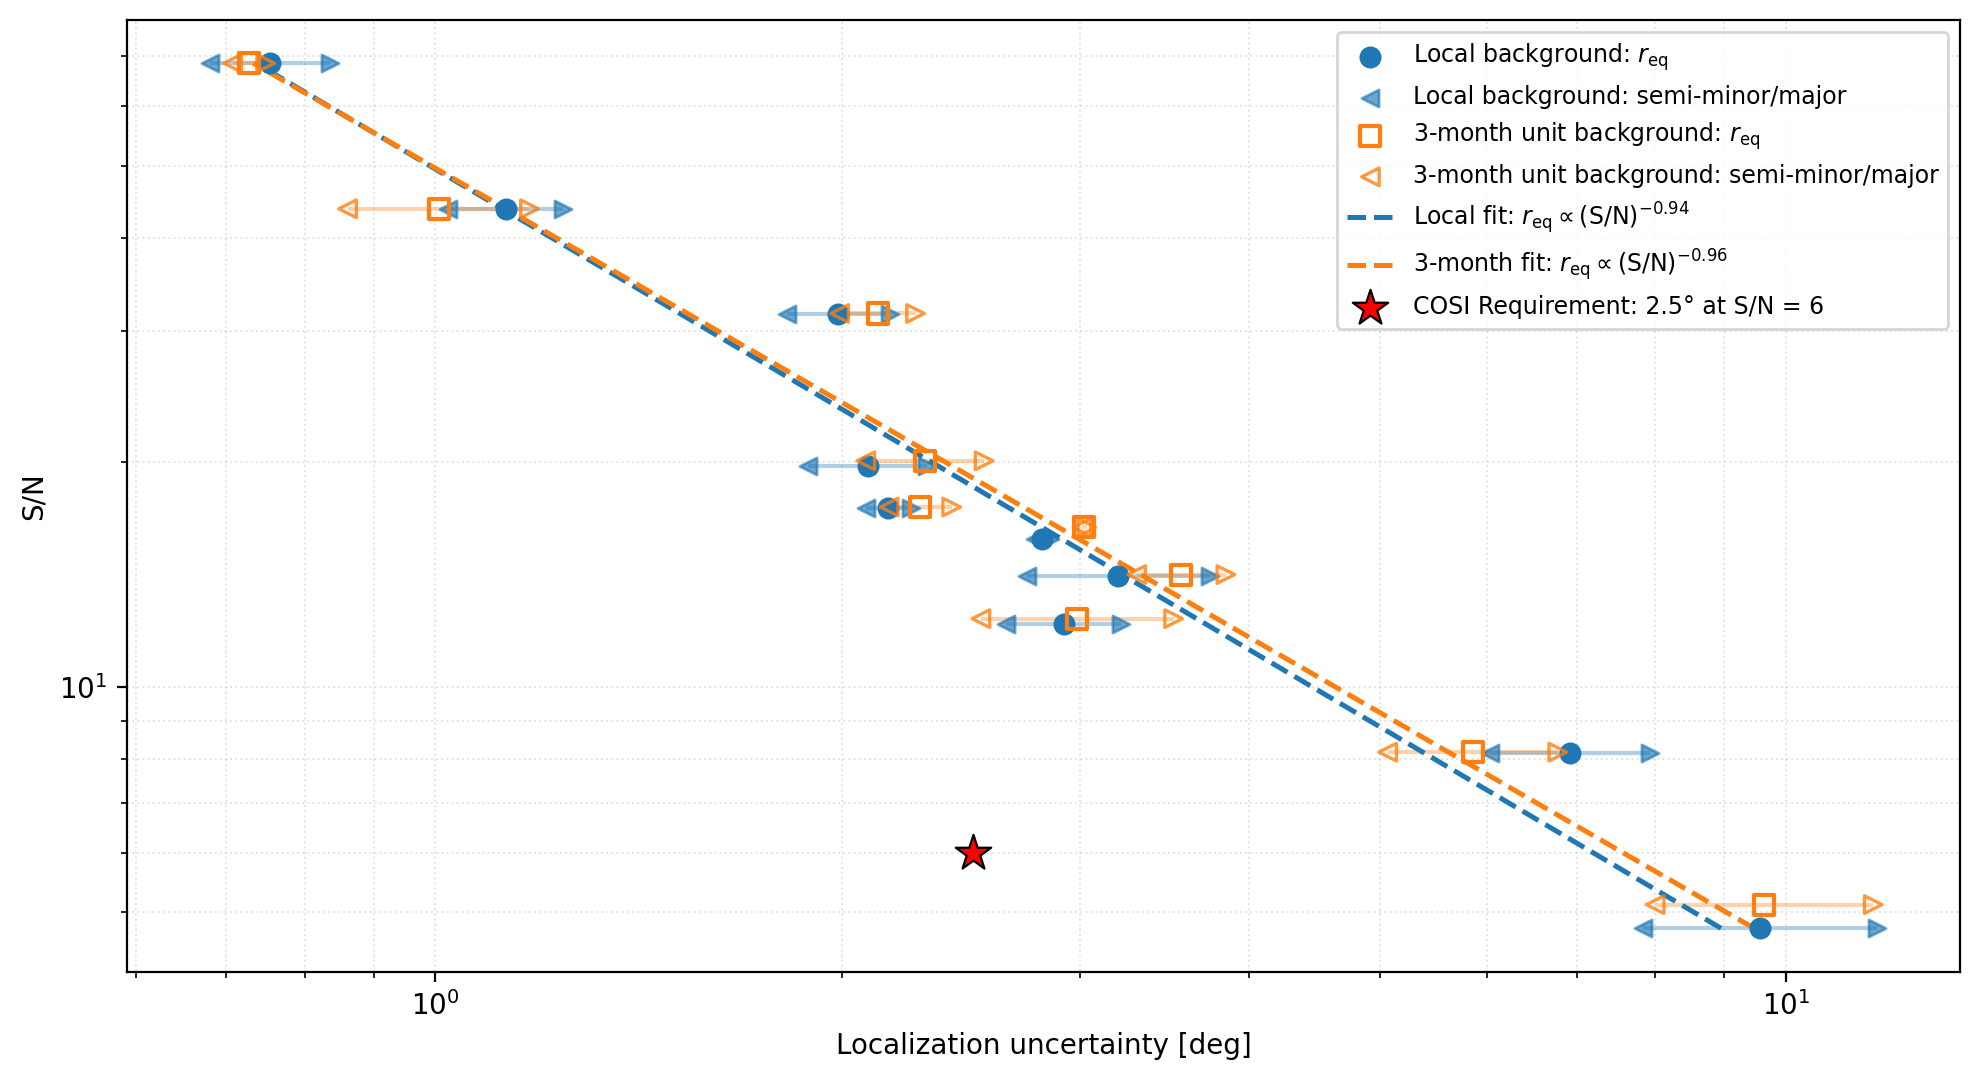

Local background
  Median semi-major axis: 2.580 deg
  Median semi-minor axis: 2.365 deg
  Median r_eq:            2.489 deg
  Mean r_eq:              3.354 deg
  Trend slope:            -0.936
  Trend normalization:    38.447

3-month unit background
  Median semi-major axis: 2.792 deg
  Median semi-minor axis: 2.351 deg
  Median r_eq:            2.645 deg
  Mean r_eq:              3.352 deg
  Trend slope:            -0.958
  Trend normalization:    42.143

3-month unit background relative to local background
  Median semi-major change: +8.21%
  Median semi-minor change: -0.60%
  Median r_eq change:        +6.26%
  Mean r_eq change:          -0.07%


In [9]:
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Local background
# ============================================================
snr_local = np.array([
    15.79, 8.15, 43.71, 31.64, 4.75,
    19.76, 17.38, 14.10, 12.15, 68.53,
])

a_local = np.array([
    2.84902822, 6.03768426, 1.24332419, 2.16954255, 11.66786767,
    2.31106241, 2.08366530, 3.74613958, 3.22030070, 0.83486117,
])

b_local = np.array([
    2.77970578, 7.93152180, 1.02217753, 1.82130352, 7.83534874,
    1.88778267, 2.24840521, 2.73982822, 2.64638959, 0.68107531,
])


# ============================================================
# 3-month unit background
# ============================================================
snr_unit_bkg = np.array([
    68.55, 8.18, 16.37, 43.75, 31.67,
    5.11, 20.10, 17.43, 14.15, 12.35,
])

a_unit_bkg = np.array([
    0.74877913, 5.06948445, 3.03536118, 1.17394353, 2.26708473,
    11.60009454, 2.54819947, 2.16740169, 3.30486006, 3.51994440,
])

b_unit_bkg = np.array([
    0.70778797, 6.77512764, 3.01077018, 0.86093091, 1.99198933,
    7.99878113, 2.08255087, 2.41106621, 3.84773565, 2.53418793,
])


def calculate_localization_quantities(a, b):
    """
    Calculate the semi-major axis, semi-minor axis, and equivalent
    circular localization radius.
    """
    a_major = np.maximum(a, b)
    b_minor = np.minimum(a, b)

    # Circular radius preserving the area of the ellipse:
    #
    # pi * r_eq**2 = pi * a_major * b_minor
    #
    r_eq = np.sqrt(a_major * b_minor)

    return a_major, b_minor, r_eq


def fit_power_law(snr, localization):
    """
    Fit the power-law relation

        localization = normalization * snr**slope

    using a linear least-squares fit in log10 space.

    Returns
    -------
    slope : float
        Power-law index.

    normalization : float
        Power-law normalization.
    """
    valid = (
        np.isfinite(snr)
        & np.isfinite(localization)
        & (snr > 0)
        & (localization > 0)
    )

    log_snr = np.log10(snr[valid])
    log_localization = np.log10(localization[valid])

    slope, log10_normalization = np.polyfit(
        log_snr,
        log_localization,
        deg=1,
    )

    normalization = 10**log10_normalization

    return slope, normalization


# ============================================================
# Calculate localization quantities
# ============================================================
a_major_local, b_minor_local, r_eq_local = (
    calculate_localization_quantities(
        a_local,
        b_local,
    )
)

a_major_unit, b_minor_unit, r_eq_unit = (
    calculate_localization_quantities(
        a_unit_bkg,
        b_unit_bkg,
    )
)


# ============================================================
# Fit power-law relationships
#
# r_eq = normalization * (S/N)**slope
# ============================================================
slope_local, norm_local = fit_power_law(
    snr_local,
    r_eq_local,
)

slope_unit, norm_unit = fit_power_law(
    snr_unit_bkg,
    r_eq_unit,
)


# Smooth S/N grid for the fitted curves
snr_min = min(
    snr_local.min(),
    snr_unit_bkg.min(),
)

snr_max = max(
    snr_local.max(),
    snr_unit_bkg.max(),
)

snr_grid = np.logspace(
    np.log10(snr_min),
    np.log10(snr_max),
    500,
)


# Evaluate fitted localization uncertainties
r_eq_fit_local = norm_local * snr_grid**slope_local
r_eq_fit_unit = norm_unit * snr_grid**slope_unit


# ============================================================
# Plot
# ============================================================
fig, ax = plt.subplots(
    figsize=(10, 5.5),
    dpi=200,
)


# ------------------------------------------------------------
# Local background:
# horizontal ranges from semi-minor to semi-major axis
# ------------------------------------------------------------
ax.hlines(
    y=snr_local,
    xmin=b_minor_local,
    xmax=a_major_local,
    color="tab:blue",
    linewidth=1.5,
    alpha=0.35,
)

ax.scatter(
    r_eq_local,
    snr_local,
    marker="o",
    s=48,
    color="tab:blue",
    label=r"Local background: $r_{\rm eq}$",
    zorder=3,
)

ax.scatter(
    b_minor_local,
    snr_local,
    marker="<",
    s=38,
    color="tab:blue",
    alpha=0.65,
    label="Local background: semi-minor/major",
    zorder=3,
)

ax.scatter(
    a_major_local,
    snr_local,
    marker=">",
    s=38,
    color="tab:blue",
    alpha=0.65,
    zorder=3,
)


# ------------------------------------------------------------
# 3-month unit background:
# horizontal ranges from semi-minor to semi-major axis
# ------------------------------------------------------------
ax.hlines(
    y=snr_unit_bkg,
    xmin=b_minor_unit,
    xmax=a_major_unit,
    color="tab:orange",
    linewidth=1.5,
    alpha=0.35,
)

ax.scatter(
    r_eq_unit,
    snr_unit_bkg,
    marker="s",
    s=52,
    facecolors="none",
    edgecolors="tab:orange",
    linewidths=1.5,
    label=r"3-month unit background: $r_{\rm eq}$",
    zorder=3,
)

ax.scatter(
    b_minor_unit,
    snr_unit_bkg,
    marker="<",
    s=40,
    facecolors="none",
    edgecolors="tab:orange",
    linewidths=1.2,
    alpha=0.8,
    label="3-month unit background: semi-minor/major",
    zorder=3,
)

ax.scatter(
    a_major_unit,
    snr_unit_bkg,
    marker=">",
    s=40,
    facecolors="none",
    edgecolors="tab:orange",
    linewidths=1.2,
    alpha=0.8,
    zorder=3,
)


# ------------------------------------------------------------
# Power-law fits
#
# The fit is defined as r_eq(S/N), but the axes are reversed.
# Therefore:
#
#     x = fitted r_eq
#     y = S/N
# ------------------------------------------------------------
ax.plot(
    r_eq_fit_local,
    snr_grid,
    linestyle="--",
    linewidth=1.8,
    color="tab:blue",
    label=(
        rf"Local fit: "
        rf"$r_{{\rm eq}}\propto(\mathrm{{S/N}})"
        rf"^{{{slope_local:.2f}}}$"
    ),
)

ax.plot(
    r_eq_fit_unit,
    snr_grid,
    linestyle="--",
    linewidth=1.8,
    color="tab:orange",
    label=(
        rf"3-month fit: "
        rf"$r_{{\rm eq}}\propto(\mathrm{{S/N}})"
        rf"^{{{slope_unit:.2f}}}$"
    ),
)

# ============================================================
# COSI Requirement
# ============================================================
ax.scatter(2.5, 6, marker="*", s=180, color="red", edgecolors="black", linewidths=0.8, label="COSI Requirement: 2.5° at S/N = 6", zorder=5)

# ============================================================
# Axes and formatting
# ============================================================
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Localization uncertainty [deg]")
ax.set_ylabel("S/N")

ax.grid(
    which="both",
    linestyle=":",
    linewidth=0.7,
    alpha=0.35,
)

ax.legend(
    fontsize=8.5,
    frameon=True,
)

fig.tight_layout()


# ============================================================
# Save figure
# ============================================================
fig.savefig(
    "snr_vs_localization_background_comparison.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    "snr_vs_localization_background_comparison.pdf",
    bbox_inches="tight",
)

plt.show()


# ============================================================
# Numerical summary
# ============================================================
print("Local background")
print(f"  Median semi-major axis: {np.median(a_major_local):.3f} deg")
print(f"  Median semi-minor axis: {np.median(b_minor_local):.3f} deg")
print(f"  Median r_eq:            {np.median(r_eq_local):.3f} deg")
print(f"  Mean r_eq:              {np.mean(r_eq_local):.3f} deg")
print(f"  Trend slope:            {slope_local:.3f}")
print(f"  Trend normalization:    {norm_local:.3f}")

print()

print("3-month unit background")
print(f"  Median semi-major axis: {np.median(a_major_unit):.3f} deg")
print(f"  Median semi-minor axis: {np.median(b_minor_unit):.3f} deg")
print(f"  Median r_eq:            {np.median(r_eq_unit):.3f} deg")
print(f"  Mean r_eq:              {np.mean(r_eq_unit):.3f} deg")
print(f"  Trend slope:            {slope_unit:.3f}")
print(f"  Trend normalization:    {norm_unit:.3f}")


# ============================================================
# Direct comparison
# ============================================================
median_r_eq_change = (
    np.median(r_eq_unit) / np.median(r_eq_local) - 1
) * 100

mean_r_eq_change = (
    np.mean(r_eq_unit) / np.mean(r_eq_local) - 1
) * 100

median_major_change = (
    np.median(a_major_unit) / np.median(a_major_local) - 1
) * 100

median_minor_change = (
    np.median(b_minor_unit) / np.median(b_minor_local) - 1
) * 100

print()
print("3-month unit background relative to local background")
print(f"  Median semi-major change: {median_major_change:+.2f}%")
print(f"  Median semi-minor change: {median_minor_change:+.2f}%")
print(f"  Median r_eq change:        {median_r_eq_change:+.2f}%")
print(f"  Mean r_eq change:          {mean_r_eq_change:+.2f}%")